# Euler's Elastica

The **Euler elastica problem** is a classical problem in mechanics describing the equilibrium shapes of an inextensible, slender elastic rod subject to bending. Originally studied by Euler in the 18th century, it remains a fundamental model in continuum mechanics, geometric variational calculus, and modern applications ranging from soft robotics to biological filaments.

Let $\mathcal{I} = [0,L] \subset \mathbb{R}$ denote a one-dimensional interval representing the material coordinates of the longitudinal axis of the rod in its undeformed, straight configuration, where $L$ is the total length of the rod. The configuration of the rod is described by the angle field $u(\sigma)$, defined as the angle between the tangent to the rod axis and the horizontal direction, evaluated at the dimensionless arc-length parameter $\sigma := s/L$.

We consider a rod with constant cross-section, clamped at the left end and subjected to a vertical end load at the right end. Under these assumptions, the boundary-value problem associated with the dimensionless continuous Euler's elastica equation reads
$$\frac{\mathrm{d}^2 u}{\mathrm{d}\sigma^2} + f \cos u = 0 \quad \text{in } (0,1), \quad u(0) = 0, \quad \frac{\mathrm{d}u}{\mathrm{d}\sigma}(1) = 0,$$
where $f = PL^2/B$ is the **dimensionless load parameter**. Here, $P < 0$ denotes the **vertical component of the load** applied at the right end, and $B$ is the **bending stiffness** of the rod.

This problem also admits the following variational formulation: find $u$ minimizing the energy functional
$$\min_{u} \;
\frac{1}{2} \int_0^1 \left( \frac{\mathrm{d}u}{\mathrm{d}\sigma} \right)^2 \, \mathrm{d}\sigma
\;-\;
\int_0^1 f \sin u \, \mathrm{d}\sigma,
\qquad
u(0) = 0.$$

In this notebook, we aim to solve this problem using the framework of DEC. Two complementary discretization strategies are considered. First, we formulate a **variational DEC approach**, in which the continuous energy functional is discretized directly using discrete differential forms and Hodge star operators, and the equilibrium configuration is obtained by minimizing the resulting discrete energy. Second, we investigate a **non-variational DEC formulation**, where the Euler–Lagrange equation is discretized directly at the level of the governing differential equation.

## Imports

In [1]:
import numpy as np
import dctkit as dt
import jax.numpy as jnp
from jax import jit, grad
from dctkit.math.opt import optctrl
from scipy import sparse
import os
from dctkit.dec import cochain as C
from dctkit.mesh import util
import matplotlib.pyplot as plt

In [2]:
dt.config()

## Complex generation and util

In [3]:
data = "data/xy_F_35.txt"
F = -35.
np.random.seed(42)

# load true data
data = np.genfromtxt(data)

# sampling factor for true data
sampling = 10

num_elements = 10

L = 1
h = L/(num_elements)

B = 7.854

# define dimensionless load
A = F*L**2/B

In [4]:
def compute_transform_u_xy(num_nodes):
    # bidiagonal matrix to transform u in (x,y)
    diag = [1]*(num_nodes)
    upper_diag = [-1]*(num_nodes-1)
    upper_diag[0] = 0
    diags = [diag, upper_diag]
    transform = sparse.diags(diags, [0, -1]).toarray()
    transform[1, 0] = -1
    return transform

def compute_true_solution(data, sampling, num_elements):
    x_true = data[:, 1][::sampling]
    y_true = data[:, 2][::sampling]
    u_true = np.empty(num_elements, dtype=dt.float_dtype)
    for i in range(num_elements):
        u_true[i] = np.arctan(
            (y_true[i+1]-y_true[i])/(x_true[i+1]-x_true[i]))

    return u_true, x_true, y_true

def reconstruct_xy(u, h, num_nodes):
    transform = compute_transform_u_xy(num_nodes)
    cos_u = h*jnp.cos(u)
    sin_u = h*jnp.sin(u)
    b_x = jnp.insert(cos_u, 0, 0)
    b_y = jnp.insert(sin_u, 0, 0)
    x = jnp.linalg.solve(transform, b_x)
    y = jnp.linalg.solve(transform, b_y)
    return x, y

In [5]:
# compute true solution
u_true, x_true, y_true = compute_true_solution(data, sampling, num_elements)

In [6]:
num_nodes = num_elements + 1
mesh, _ = util.generate_line_mesh(num_nodes, 1.)
S = util.build_complex_from_mesh(mesh)
S.get_hodge_star()

# define internal cochain to compute the energy only in the interior points
int_vec = np.ones(S.num_nodes, dtype=dt.float_dtype)
int_vec[0] = 0
int_vec[-1] = 0
int_coch = C.CochainP0(complex=S, coeffs=int_vec)
# define the unit cochain on the dual nodes
ones_coch = C.CochainD0(complex=S, coeffs=np.ones(num_elements,dtype=dt.float_dtype))

# initial guess for the angles (EXCEPT PRESCRIBED ANGLE AT LEFT END)
u_0 = np.zeros(num_elements-1, dtype=dt.float_dtype)

# cochain to zero residual on elements where BC is prescribed
mask = np.ones(num_elements, dtype=dt.float_dtype)
mask[0] = 0.

## Variational Formulation

The discrete elastica energy can be formulated as
$$\mathcal{E}_{\text{el}}(u) := \frac{1}{2} \langle k, \star d^\star u \rangle - \langle f\mathbb{1}, \sin u  \rangle,$$
where $\mathbb{1}$ is the dual one $0$-cochain, $k := \mathbb{1}_{\text{int}} \odot \star d^\star u$ is the primal $0$-cochain that encodes the (discrete) curvatures on the nodes and $\mathbb{1}_{\text{int}}$ is the primal $0$-cochain that is identically $1$ on the interior and $0$ on the boundary nodes.

In [7]:
def obj(u):
    """Computes the total potential energy.

    Args:
        u: current configuration angles.

    Returns:
        value of the energy.
    """
    # apply bc at left end
    u = jnp.insert(u, 0, u_true[0])
    u_coch = C.CochainD0(complex=S, coeffs=u)

    # curvature at internal nodes
    curvature = C.cochain_mul(int_coch, C.star(C.coboundary(u_coch)))

    # bending moment
    moment = curvature

    # potential of the applied load
    A_coch = C.scalar_mul(ones_coch, A)
    load = C.inner(C.sin(u_coch), A_coch)

    energy = 0.5*C.inner(moment, curvature) - load

    return energy

In [8]:
prb = optctrl.OptimizationProblem(
        dim=num_elements-1, state_dim=num_elements-1, objfun=obj)

prb.set_obj_args({})
sol = prb.solve(x0=u_0)

In [9]:
u = jnp.insert(sol, 0, u_true[0])

x, y = reconstruct_xy(u, h, num_nodes)

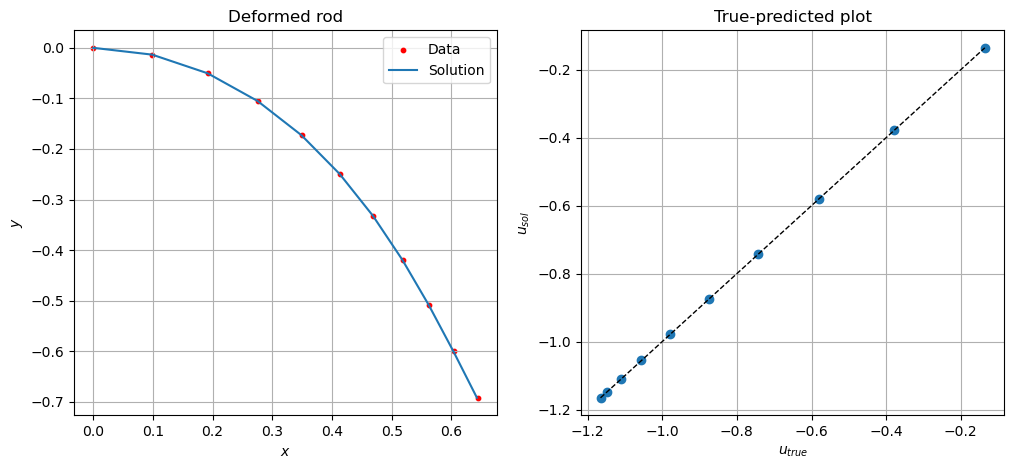

In [11]:
plt.figure(1, figsize=(12, 5))
_, ax = plt.subplots(1, 2, num=1)

# plot (x,y) true and (x,y) predicted
ax[0].scatter(x,y, s=10, c="r", label="Data")
ax[0].plot(x_true, y_true, label="Solution")
ax[0].legend()
ax[0].grid()
ax[0].set_xlabel(r"$x$")
ax[0].set_ylabel(r"$y$")
ax[0].set_title("Deformed rod")

# u_true vs u_predicted plot
u_min = min(u_true.min(), u.min())
u_max = max(u_true.max(), u.max())
ax[1].scatter(u_true, u)
ax[1].grid()
ax[1].plot([u_min, u_max], [u_min, u_max], "k--", linewidth=1)
ax[1].set_xlabel(r"$u_{true}$")
ax[1].set_ylabel(r"$u_{sol}$")
ax[1].set_title("True-predicted plot")
plt.show()

## Non-variational formulation

Computing the first variation of the discrete elastica energy, we obtain the discrete Euler's Elastica equation:
$$\delta \star k - f \cos(u) = 0,$$
which is equivalent, using the definition of the codifferential, to
$$-\star d k - f \cos(u) = 0.$$

In [12]:
def obj(x):
    # apply Dirichlet BC at left end
    u = jnp.insert(x, 0, u_true[0])
    u_coch = C.CochainD0(S, u)

    # dimensionless curvature at primal nodes (primal 0-cochain)
    du = C.coboundary(u_coch)
    curv = C.cochain_mul(int_coch, C.star(du))

    load = C.scalar_mul(C.cos(u_coch), A)

    # dimensionless bending moment
    moment = curv

    residual = C.sub(C.codifferential(C.star(moment)), load)

    return jnp.linalg.norm(residual.coeffs[1:])

In [13]:
prb = optctrl.OptimizationProblem(
        dim=num_elements-1, state_dim=num_elements-1, objfun=obj)

prb.set_obj_args({})
sol = prb.solve(x0=u_0)

In [14]:
u = jnp.insert(sol, 0, u_true[0])

x, y = reconstruct_xy(u, h, num_nodes)

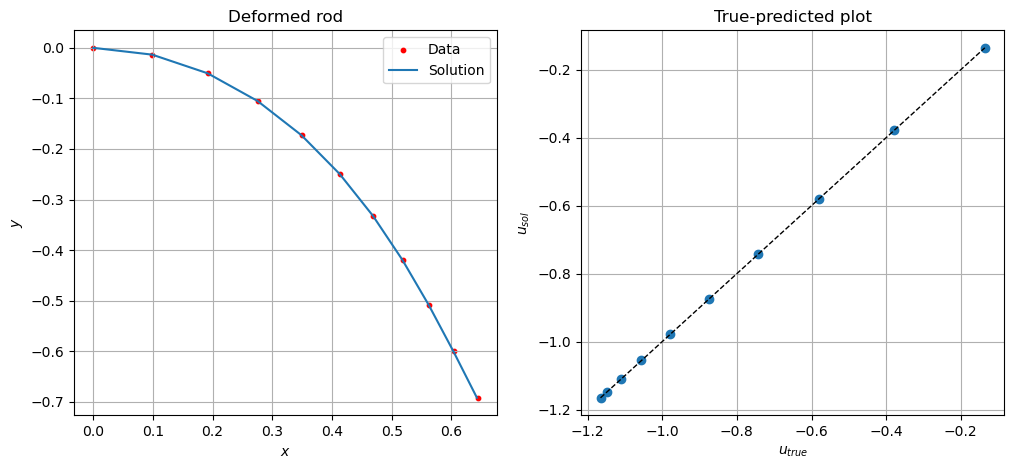

In [15]:
plt.figure(1, figsize=(12, 5))
_, ax = plt.subplots(1, 2, num=1)

# plot (x,y) true and (x,y) predicted
ax[0].scatter(x,y, s=10, c="r", label="Data")
ax[0].plot(x_true, y_true, label="Solution")
ax[0].legend()
ax[0].grid()
ax[0].set_xlabel(r"$x$")
ax[0].set_ylabel(r"$y$")
ax[0].set_title("Deformed rod")

# u_true vs u_predicted plot
u_min = min(u_true.min(), u.min())
u_max = max(u_true.max(), u.max())
ax[1].scatter(u_true, u)
ax[1].plot([u_min, u_max], [u_min, u_max], "k--", linewidth=1)
ax[1].grid()
ax[1].set_xlabel(r"$u_{true}$")
ax[1].set_ylabel(r"$u_{sol}$")
ax[1].set_title("True-predicted plot")
plt.show()